<a href="https://colab.research.google.com/github/barbarahatano/USP/blob/main/4_semestre/calculo_numerico/trabalho_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

&nbsp;&nbsp;&nbsp;&nbsp;Bárbara Naomi Morimoto Hatano

&nbsp;&nbsp;&nbsp;Exercício 1: Ambos os códigos implementam o método de Decomposição LU de uma matriz A, onde A = LU, com L sendo uma matriz triangular inferior  U uma matriz triangular superior. Este método é fundamental para resolver sistemas de equaçoes lineares.

&nbsp;&nbsp;&nbsp;A func1 implementa a decomposição padrão, associada ao método de eliminação de Gauss. Os loops iteram sobre todos os elementtos abaixo da diagonal principal para zerá-los (na matriz U) e armazenar os multiplicadores (na matriz L). Para uma matriz nxn, a complexidade de tempo é de O(n³) por conta dos 3 laços de repetição alinhados (os dois for i in range e o loop implícito de fatiamento da matriz), a qual é uma complexidade alta que resultou, no exemplo dado, num tempo de aproximadamente 24,48 segundos.

&nbsp;&nbsp;&nbsp;Por outro lado, a func2 implementa uma versão modificada da decomposição LU, aproveitando a estrutura de banda da matriz A, no exemplo ela tem uma largura de banda p=2, a qual limita a iteração e aproveita o fato de que, em uma matriz de banda, a maioria dos multiplicadores será 0 fora da banda e as operações de eliminação só precisam ser realizadas dentro da largura de banda p. Com isso a complexidade de tempo é reduzida significativamente, como p << n, a complexidade cai para O(np²)~O(n), que resultou num tempo de execução de 0,03 segundo, aproximadamente.

&nbsp;&nbsp;&nbsp;Contudo, apesar dessas diferenças consideráveis de tempo de execução, os resultados encontrados são os mesmos, 2.319965075229418e-13, mostrando que a forma de banda otimiza apenas a velocidade do cálculo sem haver perda de precisão em comparação com o LU clássico sem pivoteamento.

In [ ]:
import numpy as np
import time

def func1 ( A ) :   #Eliminação de Gauss
  n = A.shape[0]
  U = A.copy() # Inicializa U como uma cópia da matriz original A
  L = np.eye(n) # Inicializa L como uma matriz identidade n x n
  for j in range ( n - 1 ) : # Loop pelas colunas (exceto a última)
    for i in range ( j + 1 , n ) : # Loop pelas linhas abaixo da diagonal principal
      # Calcula o multiplicador L[i,j] que zera o elemento U[i,j]
      L [ i , j ] = U[ i , j ] / U[ j , j ]
      # Atualiza a linha i da matriz U, aplicando a operação de eliminação
      # Subtrai L[i,j] * linha j de U da linha i de U
      U[ i , j : n ] = U[ i , j : n ] - L [ i , j ] * U[ j , j : n ]
  return ( L, U )

def func2(A,p):
  n=A.shape[0]
  U=A.copy() # Inicializa U como uma cópia da matriz original A
  L=np.eye(n) # Inicializa L como uma matriz identidade n x n

  for j in range(n-1): # Loop pelas colunas (exceto a última)
    # 'v' define o limite superior para o loop das linhas, considerando a largura de banda 'p'
    # Isso otimiza o cálculo para matrizes de banda, evitando operações desnecessárias
    v = min(n, j+p+1)
    for i in range(j+1, v): # Loop pelas linhas abaixo da diagonal, dentro da banda
      # Calcula o multiplicador L[i,j] que zera o elemento U[i,j]
      L[i,j]= U[i,j]/U[j,j]
      # Atualiza a linha i da matriz U, aplicando a operação de eliminação
      # A operação é restrita à largura de banda 'v' para otimização
      U[i,j:v]=U[i,j:v]-L[i,j]*U[j,j:v]
  return (L,U)

n = 2000
p=2
A=np.zeros((n,n))

for i in range (n):
  for j in range(max(0, i-p), min(n, i+p+1)):
    A[i,j]=np.random.normal()

start_time=time.time()
(L, U)=func1(A)
end_time=time.time()
print(end_time-start_time)

start_time=time.time()
(L_,U_)=func2(A,p)
end_time=time.time()
print(end_time-start_time)

print(np.linalg.norm(L@U-A))
print(np.linalg.norm(L_ @ U_ -A))

24.48355770111084
0.05650782585144043
1.3685430639676118e-13
1.3685430639676118e-13


-----------------------------------

&nbsp;&nbsp;&nbsp;Exercício 2: a-) O método da bisseção é um método iterativo de intervalo fechado, o qual utiliza o intervalo inicial [3.1,3.2], tirado do gráfico, e é aplicado com pricisão e=0.001 e máximo de 5 iterações

&nbsp;&nbsp;&nbsp;O método da bisseção garante que a largura do intervalo diminua pela metade a cada iteração, convergência linear, e, desde que f(a)*f(b) < 0, a convergência para a raiz é garantida. O critério de parada utilizado inclui o limite de 5 iterações e a precisão ||b-a||/2 < 0.001. Sua única desvantagem é o fato de sua convergência ser lenta, no exemplo, com 5 iterações ele falha em reduzir o erro para 0.001, chegando apenas em 0.00315.

&nbsp;&nbsp;&nbsp;Contudo, sua resposta ainda está dentro do erro chegando ao resultado de x*=3.1734375000 e h=6.5464819336, após chegar no limite de iterações definido (5).

In [ ]:
import numpy as np

# --- Funções do Problema ---
def p(x):
    """Perfil da elevação."""
    return -x**4 + 7.7*x**3 - 18*x**2 + 13.6*x

def q(x):
    """Curva do projétil."""
    return -x**2 + 5*x + 0.75

def f(x):
    """Função cuja raiz é procurada: f(x) = p(x) - q(x)."""
    return p(x) - q(x)

# --- Implementação do Método da Bisseção ---
def bissecao(f, a, b, tol, max_iter):
    if f(a) * f(b) >= 0:  #Verificação para ver se o método da Bisseção pode ser aplicado
        print("Erro: f(a) e f(b) devem ter sinais opostos. Tente outro intervalo.")
        return None, None

    iteracoes = 0
    print("| i |   a    |   b    |   xm   | f(xm)  | |b-a| ")
    print("|---|--------|--------|--------|--------|-------|")

    while (b - a) / 2 > tol and iteracoes < max_iter:
        xm = (a + b) / 2  #Calcula o x médio
        f_a = f(a)
        f_xm = f(xm)

        print(f"| {iteracoes+1} | {a:.4f} | {b:.4f} | {xm:.4f} | {f_xm:.4f} | {b-a:.4f} |")

        if f_xm == 0:   #Se o valor da função do x médio for 0, encontrou-se a raiz e para a função
            a = b = xm
            break
        elif f_a * f_xm < 0:   #Se a raiz se encontra entre o a e o xm, atualiza-se o valor de b para buscar a raiz entre a e xm
            b = xm             #Pega-se a primeira metade do intervalo
        else:                  #Caso contrário, a raiz se encontra entre o xm e o b, logo atualiza-se a->xm para buscar entre esse novo intervalo
            a = xm

        iteracoes += 1        #Incrementa para a próxima iteração

    x_aprox = (a + b) / 2
    return x_aprox, q(x_aprox)

# --- Parâmetros e Execução ---
a_bissecao = 3.1
b_bissecao = 3.2
tolerancia = 0.001
max_i_bissecao = 5

print("### Resultados do Método da Bisseção (Exercício 2.a) ###")
raiz_b, altura_b = bissecao(f, a_bissecao, b_bissecao, tolerancia, max_i_bissecao)

if raiz_b is not None:
    print("\n--- Conclusão ---")
    print(f"Posição de Impacto (x*): {raiz_b:.10f}")
    print(f"Altura de Impacto (h): {altura_b:.10f}")
    print(f"Iterações realizadas: {max_i_bissecao} (Limite atingido)")

### Resultados do Método da Bisseção (Exercício 2.a) ###
| i |   a    |   b    |   xm   | f(xm)  | |b-a| 
|---|--------|--------|--------|--------|-------|
| 1 | 3.1000 | 3.2000 | 3.1500 | -0.1283 | 0.1000 |
| 2 | 3.1500 | 3.2000 | 3.1750 | 0.0115 | 0.0500 |
| 3 | 3.1500 | 3.1750 | 3.1625 | -0.0578 | 0.0250 |
| 4 | 3.1625 | 3.1750 | 3.1688 | -0.0230 | 0.0125 |
| 5 | 3.1688 | 3.1750 | 3.1719 | -0.0057 | 0.0063 |

--- Conclusão ---
Posição de Impacto (x*): 3.1734375000
Altura de Impacto (h): 6.5464819336
Iterações realizadas: 5 (Limite atingido)


&nbsp;&nbsp;&nbsp;b-) Por outro lado, o método de Newton para sistemas é um método de intervalo aberto. Ele se baseia numa expansão de Taylor de primeira ordem, aproximação linear, para calcular o próximo passo de correção delta(x). O processo para quando a norma do passo de correção for menor que a precisão e=0.001.

&nbsp;&nbsp;&nbsp;O método de Newton tem convergência quadrática desde que o chute incial seja bom e a Jacobiana não seja singular na raiz. O chute inicial para esse caso foi baseado no gráfico x0= [3.2,6.7].

&nbsp;&nbsp;&nbsp;Com esses dados, chegou-se na posição de impacto x*=3.1729163047 e h=6.5471836469 com 3 iterações até alcançar a condição de parada e=0.001.

In [ ]:
import numpy as np

# --- Funções do Problema (Reutilizadas) ---
def p(x):
    return -x**4 + 7.7*x**3 - 18*x**2 + 13.6*x

def q(x):
    return -x**2 + 5*x + 0.75

# --- Formulação do Sistema F(x, y) ---
def F(x, y):
    """Sistema de funções F(x, y) = 0."""
    # f1(x, y) = y - p(x) = 0
    f1 = y - p(x)
    # f2(x, y) = y - q(x) = 0
    f2 = y - q(x)
    return np.array([f1, f2])

# --- Matriz Jacobiana J(x, y) ---
def J(x, y):
    """Matriz Jacobiana J para F(x, y)."""
    # df1/dx = -p'(x) = -(-4x^3 + 23.1x^2 - 36x + 13.6)
    df1_dx = 4*x**3 - 23.1*x**2 + 36*x - 13.6
    # df1/dy = 1
    df1_dy = 1.0
    # df2/dx = -q'(x) = -(-2x + 5) = 2x - 5
    df2_dx = 2*x - 5.0
    # df2/dy = 1
    df2_dy = 1.0

    return np.array([
        [df1_dx, df1_dy],
        [df2_dx, df2_dy]
    ])

# --- Implementação do Método de Newton ---
def newton_sistemas(F, J, x0, tol, max_iter=50):
    # x_k é o vetor de aproximações (x, y) na iteração k
    x_k = np.array(x0)

    print("| i |    x    |    y    | ||x(k)-x(k-1)||∞ |")
    print("|---|---------|---------|------------------|")

    for k in range(max_iter):
        # Avalia o sistema de funções F e a Jacobiana J na aproximação atual x_k
        F_k = F(x_k[0], x_k[1])
        J_k = J(x_k[0], x_k[1])

        try:
            # Resolve o sistema linear J_k * delta_x = -F_k para encontrar o passo de correção delta_x
            # delta_x = [delta_x_coord, delta_y_coord]
            delta_x = np.linalg.solve(J_k, -F_k)
        except np.linalg.LinAlgError:
            # Captura erro se a matriz Jacobiana for singular (não invertível)
            print("\nErro: Matriz Jacobiana Singular. O método falhou.")
            return None

        # Atualiza a aproximação: x_k_novo = x_k + delta_x
        x_k_novo = x_k + delta_x
        # Calcula o erro usando a norma infinita do passo de correção (máximo absoluto)
        erro = np.linalg.norm(delta_x, ord=np.inf)

        # Imprime o progresso da iteração
        print(f"| {k+1} | {x_k_novo[0]:.6f} | {x_k_novo[1]:.6f} | {erro:.6e} |")

        # Verifica o critério de parada: se o erro é menor que a tolerância
        if erro < tol:
            # Retorna a nova aproximação se a convergência for atingida
            return x_k_novo

        # Atualiza x_k para a próxima iteração
        x_k = x_k_novo

    # Se o loop terminar sem atingir a tolerância, o máximo de iterações foi atingido
    print("\nAviso: Máximo de iterações atingido.")
    return x_k

# --- Parâmetros e Execução ---
chute_inicial = [3.2, 6.7] # Próximo ao pico no gráfico
tolerancia = 0.001

print("\n### Resultados do Método de Newton para Sistemas (Exercício 2.b) ###")
raiz_n = newton_sistemas(F, J, chute_inicial, tolerancia)

if raiz_n is not None:
    print("\n--- Conclusão ---")
    print(f"Posição de Impacto (x*): {raiz_n[0]:.10f}")
    print(f"Altura de Impacto (h): {raiz_n[1]:.10f}")
    print(f"Tolerância alcançada: {tolerancia}")


### Resultados do Método de Newton para Sistemas (Exercício 2.b) ###
| i |    x    |    y    | ||x(k)-x(k-1)||∞ |
|---|---------|---------|------------------|
| 1 | 3.172307 | 6.548771 | 1.512291e-01 |
| 2 | 3.172916 | 6.547184 | 1.586474e-03 |
| 3 | 3.172916 | 6.547184 | 7.441686e-07 |

--- Conclusão ---
Posição de Impacto (x*): 3.1729163047
Altura de Impacto (h): 6.5471836469
Tolerância alcançada: 0.001


&nbsp;&nbsp;&nbsp;Ambos os método conseguiram aproximar o ponto de impacto na região da maior elevação, no entanto, houve diferenças significativas na precisão e na eficiência:

| Método | x* | h | iterações |
| :---: | :---: | :---: | :---: |
| **bisseção** | 3.1734375000 | 6.5464819336 | 5 |
| **newton** | 3.1729163047 | 6.5471836469 | 3 |

&nbsp;&nbsp;&nbsp;Enquanto a bisseção alcançou o limite de iterações e não chegou no erro desejado (e=0.001), newton precisou de duas iterações a menos para alcançar o erro graças a sua convergência quadrática, apesar de ambos convergirem para uma aproximação extremamente próxima.

--------------------------------

&nbsp;&nbsp;&nbsp;Exercício 3: a-) O método de Francis é um algoritmo iterativo usado para calcular todos os autovalores de uma matriz. Quando aplicado a uma matriz $\mathcal{B}_{n \times n}$ a iteração é definida pelos seguintes passos em cada passo k:

&nbsp;&nbsp;1.  **Decomposição QR**: Decompõe-se a matriz atual $\mathcal{B}_{k}$ em um produto de uma matriz ortogonal $\mathcal{Q}_{k}$ e uma matriz triangular superior $\mathcal{R}_{k}$

&nbsp;&nbsp;2.  **Recombinação**: A matriz da próxima iteração é formada multiplicando as mesmas matrizes R e Q na ordem inversa.

&nbsp;&nbsp;&nbsp;Essa sequência de matrizes B converge para uma matriz diagonal ou quase diagonal, nas quais as entradas na diagonal de $\mathcal{B}_{k}$ forncem aproximanções para os autovalores de B. Além disso as matrizes são semelhantes, o que garante que elas possuem os mesmos autovalores. A matriz que realiza essa transformação de similaridade é $V = \mathcal{Q}_{1} \mathcal{Q}_{2} \cdots \mathcal{Q}_{k-1}$ e as colunas de V são aproximações os respectivos autovetores de B.

In [ ]:
import numpy as np

def metodo_francis(B, max_iter=100, tol=1e-8):
    """
    Implementa o Método de Francis (QR Iterativo) para encontrar autovalores
    e autovetores de uma matriz simétrica B.

    Argumentos:
        B (numpy.array): Matriz simétrica.
        max_iter (int): Número máximo de iterações.
        tol (float): Tolerância para o critério de parada off(B).

    Retorna:
        tuple: (B_k final - matriz diagonalizada, V - matriz dos autovetores)
    """

    # 1. Inicialização: V é a matriz identidade, acumula Qk
    B_k = B.copy()
    n = B_k.shape[0]
    V = np.eye(n) # Matriz V = Q1 * Q2 * ... * Qk-1

    for k in range(1, max_iter + 1):
        # 2. Decomposição QR: Bk = Qk * Rk
        Q_k, R_k = np.linalg.qr(B_k)

        # 3. Recombinação: B_k+1 = Rk * Qk
        B_k_next = R_k @ Q_k

        # 4. Atualização da matriz de autovetores V = V * Qk
        V = V @ Q_k

        # 5. Critério de Parada (off-diagonal)
        # off(B) = sqrt(||B||_F^2 - sum(b_ii^2))
        diag_sum_sq = np.sum(np.diag(B_k_next)**2)
        norm_F_sq = np.sum(B_k_next**2)
        off_B = np.sqrt(norm_F_sq - diag_sum_sq)


        if off_B < tol:
            print(f"Convergência alcançada na iteração {k} (off(B) = {off_B:.2e} < {tol:.0e})")
            return B_k_next, V

        B_k = B_k_next

    print(f"Aviso: Máximo de {max_iter} iterações atingido (off(B) = {off_B:.2e}).")
    return B_k, V

# Exemplo de uso (Não exigido, mas útil para testes)
B_test = np.array([[4, 1, 1], [1, 3, 2], [1, 2, 5]])
Autovalores, Autovetores = metodo_francis(B_test)
print("\nAutovalores (Diagonal de B_k):\n", np.diag(Autovalores))
print("\nAutovetores (Colunas de V):\n", Autovetores)

Convergência alcançada na iteração 27 (off(B) = 0.00e+00 < 1e-08)

Autovalores (Diagonal de B_k):
 [6.89510652 3.39729507 1.70759841]

Autovetores (Colunas de V):
 [[-0.43170414  0.88573564  0.1705987 ]
 [-0.49725361 -0.0758934  -0.86427949]
 [-0.75257583 -0.45794386  0.47319874]]


&nbsp;&nbsp;&nbsp;b-) A SVD é $A = U \sum V^T$. A estratégia será usar o método implementado no item anterior para encontrar $V e \sum$ a partir de $A^T A$, e então usar a própria definição da SVD para calcular U.

In [ ]:
import numpy as np

# A função metodo_francis() é assumida como definida anteriormente

def svd_francis(A, tol_francis=1e-10):
    """
    Calcula a SVD de uma matriz A usando o Método de Francis em A^T A.

    Argumentos:
        A (numpy.array): Matriz m x n.
        tol_francis (float): Tolerância para o método Francis.

    Retorna:
        tuple: (U, S_vec, VT) onde S_vec é o vetor de valores singulares.
    """
    m, n = A.shape

    # 1. Calcular a matriz simétrica B = A^T A
    B = A.T @ A

    # 2. Aplicar o Método de Francis para obter Sigma^2 e V
    Sigma_sq_mat, V = metodo_francis(B, tol=tol_francis)

    # 3. Extrair autovalores, ordenar e calcular S_vec
    autovalores = np.diag(Sigma_sq_mat)

    # Ordenar autovalores em ordem decrescente e reordenar V
    idx = np.argsort(autovalores)[::-1]
    autovalores = autovalores[idx]
    V = V[:, idx]

    # Valores singulares (raiz quadrada e lida com erros de arredondamento)
    S_vec = np.sqrt(np.maximum(autovalores, 0.0))
    k = min(m, n)

    # 4. Construir Sigma (matriz m x n) e calcular U
    U = np.zeros((m, m))

    for i in range(k):
        sigma_i = S_vec[i]

        # Calcular U[:, i] = (A * V[:, i]) / sigma_i
        if sigma_i > 1e-10: # Se o valor singular não for zero
            u_i = (A @ V[:, i]) / sigma_i
            U[:, i] = u_i
        else:
            # Para valores singulares zero, o vetor correspondente deve ser ortonormal
            # aos demais. Para simplificar, usamos uma normalização se possível.
            vec = A @ V[:, i]
            norm_vec = np.linalg.norm(vec)
            if norm_vec > 1e-10:
                 U[:, i] = vec / norm_vec

    # 5. Se m != n, U precisa ser completada com vetores ortonormais para ser m x m.
    # O método correto envolve aplicar Francis em A A^T, mas para completar uma base ortonormal:
    if m > k:
        # Usamos uma base ortonormal da coluna k até m para completar U (simplificação)
        Q_temp, _ = np.linalg.qr(np.random.rand(m, m))
        U[:, k:] = Q_temp[:, k:] # Preenche as colunas restantes de U

    VT = V.T

    # Retorna U, vetor de valores singulares, e VT
    return U, S_vec, VT

&nbsp;&nbsp;&nbsp;c-) A SVD é uma ferramenta poderosa para compressão de dados porque os valores singulares $\sigma_i$ estão ordenados de forma decrescente. A informação mais importante de uma matriz A está concentrada nos primeiros k maiores valores singulares.

&nbsp;&nbsp;&nbsp;A matriz original $\mathcal{A}_{m \times n}$ pode ser vista como a soma de min{m,n} matrizes de posto 1: $$A = \sum_{i=1}^{\min{m,n}}\sigma_i u_i v_{i}^{T}$$

&nbsp;&nbsp;&nbsp;A aproximação comprimida $A_{k}$ (matriz de posto k) é obtida truncando esta soma e retendo apenas os k maiores valores singulares, onde $k < \min(m,n)$. O processo envolve carregar a imagem como uma matriz de pixels, calcular sua SVD e reconstruir $A_k$

Imagem original carregada: 324x324 pixels.


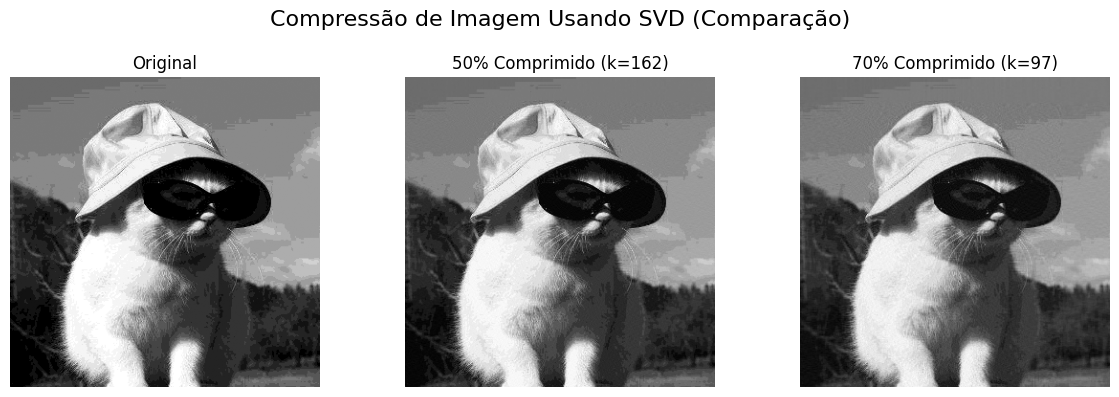

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

def compress_and_plot_svd(file_path, compression_percentages):
    """
    Carrega a imagem em escala de cinza, comprime usando SVD e plota os resultados.
    """
    try:
        # Carregar a imagem e converter para escala de cinza (matriz A)
        A = imread(file_path)
        if A.ndim == 3:
             # Converte RGB para escala de cinza (média)
             A = np.mean(A, axis=2)

        m, n = A.shape
        min_dim = min(m, n)
        print(f"Imagem original carregada: {m}x{n} pixels.")

    except FileNotFoundError:
        print(f"Erro: O arquivo '{file_path}' (cat.png) não foi encontrado.")
        return

    # Usar SVD do Numpy para precisão na compressão
    U, S_vec, VT = np.linalg.svd(A)

    num_plots = len(compression_percentages) + 1
    fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4))

    # 1. Plotar a Imagem Original
    axes[0].imshow(A, cmap='gray')
    axes[0].set_title(f"Original")
    axes[0].axis('off')

    # 2. Aplicar e Plotar as Compressões
    for i, perc in enumerate(compression_percentages):
        # O percentual de compressão (p) corresponde a reter (100-p)% dos valores singulares.
        # k = número de valores singulares retidos.
        k = int(min_dim * (1 - perc / 100))
        if k < 1: k = 1

        # Reconstrução da matriz A_k (posto k)

        # A compressão é dada por: U[:,:k] * Sigma[:k,:k] * V^T[:k,:]
        # Multiplicação do vetor S_vec[:k] pelas submatrizes de U e VT
        Ak = U[:, :k] @ np.diag(S_vec[:k]) @ VT[:k, :]

        # Comparação dos Resultados
        axes[i+1].imshow(Ak, cmap='gray')
        axes[i+1].set_title(f"{perc}% Comprimido (k={k})")
        axes[i+1].axis('off')

    plt.suptitle("Compressão de Imagem Usando SVD (Comparação)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

file_name = '/content/cat.png'
compression_percs = [50, 70]
compress_and_plot_svd('/content/cat.png', compression_percs)


----------------------------

&nbsp;&nbsp;&nbsp;Exercício 4: a-) O polinômio de Lagrange de grau n é dado pela soma dos produtos dos valores da função $f(t_i)$ pelos polinômios de base de Lagrange $L_i (t)$: $$P_n (t)= \sum_{i=0}^{n} f(t_i)L_i (t)$$

&nbsp;&nbsp;&nbsp;Onde cada polinômio de base $L_i (t)$ é definido por: $$L_i (t) = \prod_{j=0,j \neq i}^{n} \frac{t-t_j}{t_i-t_j}$$

&nbsp;&nbsp;&nbsp;O polinômio de Newton utiliza as diferenças divididas $(f[t_0], f[t_0,t_1], \cdots)$ para construir o polinômio de forma incremental: $$P_n(t) = f[t_0] + f[t_0, t_1](t - t_0) + f[t_0, t_1, t_2](t - t_0)(t - t_1) + \cdots + f[t_0, \ldots, t_n] \prod_{i=0}^{n-1} (t - t_i)$$

&nbsp;&nbsp;&nbsp;O principal benefício do método de Newton é que, ao adicionar um novo ponto, não é necessário recalcular todo o polinômio.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Função a ser interpolada (Função de Runge)
def f_runge(t):
    return 1.0 / (1.0 + 25.0 * t**2)

# --- 1. Interpolação de Lagrange ---
def lagrange_interp(t_nodes, f_nodes, t_eval):
    """
    Calcula o Polinômio de Interpolação de Lagrange no ponto t_eval.
    t_nodes: nós de interpolação (array de pontos x).
    f_nodes: valores da função nos nós (array de valores f(x)).
    t_eval: ponto ou array de pontos onde o polinômio será avaliado.
    """
    n = len(t_nodes)

    # Garantir que t_eval seja um array para operações vetorizadas
    if not isinstance(t_eval, np.ndarray):
        t_eval = np.array([t_eval])

    P_t = np.zeros_like(t_eval, dtype=float)

    # Itera sobre cada nó de interpolação para construir o polinômio
    for i in range(n):
        L_i_t = np.ones_like(t_eval, dtype=float) # Inicializa o polinômio de base Li(t) com 1s
        # Constrói o i-ésimo polinômio de base de Lagrange L_i(t)
        for j in range(n):
            if i != j:
                # L_i(t) = Produto de (t - t_j) / (t_i - t_j) para j != i
                L_i_t *= (t_eval - t_nodes[j]) / (t_nodes[i] - t_nodes[j])

        # Soma f(t_i) * L_i(t) para obter o polinômio de Lagrange completo
        P_t += f_nodes[i] * L_i_t

    return P_t

# --- 2. Interpolação de Newton (Diferenças Divididas) ---
def newton_diff_div(t_nodes, f_nodes):
    """
    Calcula a tabela de diferenças divididas para o Polinômio de Newton.
    Retorna o vetor de coeficientes (a primeira linha da matriz de diferenças divididas).
    """
    n = len(t_nodes)
    F = np.zeros((n, n)) # Matriz para armazenar as diferenças divididas
    F[:, 0] = f_nodes    # A primeira coluna é preenchida com os valores da função f(t_i)

    # Preenche a tabela de diferenças divididas diagonalmente
    for j in range(1, n): # Colunas da matriz F
        for i in range(n - j): # Linhas da matriz F
            # Fórmula da diferença dividida de ordem j: F[i, j] = (F[i+1, j-1] - F[i, j-1]) / (t_nodes[i+j] - t_nodes[i])
            F[i, j] = (F[i+1, j-1] - F[i, j-1]) / (t_nodes[i+j] - t_nodes[i])

    # Retorna o vetor de coeficientes (primeira linha da matriz F, que contém f[t0], f[t0,t1], etc.)
    return F[0, :]

def newton_interp(t_nodes, coeffs, t_eval):
    """
    Avalia o Polinômio de Interpolação de Newton no ponto t_eval.
    t_nodes: nós de interpolação.
    coeffs: coeficientes (diferenças divididas) calculados por newton_diff_div.
    t_eval: ponto ou array de pontos onde o polinômio será avaliado.
    """
    n = len(t_nodes)

    if not isinstance(t_eval, np.ndarray):
        t_eval = np.array([t_eval])

    P_t = np.zeros_like(t_eval, dtype=float)

    # Avalia o polinômio de Newton para cada ponto em t_eval
    for k in range(len(t_eval)):
        P_t[k] = coeffs[0] # O primeiro termo é f[t0]
        temp_prod = 1.0    # Inicializa o produto (t - t_i)

        # Adiciona os termos restantes do polinômio de Newton
        for i in range(1, n):
            temp_prod *= (t_eval[k] - t_nodes[i-1]) # Acumula o produto (t - t0)(t - t1)...(t - t_{i-1})
            P_t[k] += coeffs[i] * temp_prod      # Adiciona o termo f[t0,...,ti] * (t - t0)...(t - t_{i-1})

    return P_t

# Funções auxiliares para uso nos itens seguintes
def get_equispaced_nodes(a, b, N):
    return np.linspace(a, b, N)

def plot_results(t_dense, f_dense, t_nodes, f_lagrange, f_newton, title):
    plt.figure(figsize=(10, 6))
    plt.plot(t_dense, f_dense, 'k', label='Função Exata $f(t)$', linewidth=2)
    plt.plot(t_nodes, f_runge(t_nodes), 'ro', label='Nós de Interpolação', markersize=6)
    plt.plot(t_dense, f_lagrange, 'b--', label='Interpolação de Lagrange', linewidth=1.5)
    plt.plot(t_dense, f_newton, 'g:', label='Interpolação de Newton', linewidth=1.5)
    plt.title(title, fontsize=14)
    plt.xlabel('t')
    plt.ylabel('$f(t)$ e $P_n(t)$')
    plt.legend()
    plt.grid(True)
    plt.show()

&nbsp;&nbsp;&nbsp;b-) As duas soluções de Lagrange e Newton são matematicamente idênticas. O polinômio que interpola n+1 pontos é único. Embora Lagrange e Newton utilizem formulações distintas (bases polinomiais vs diferenças divdidas), ela representam o mesmo polinômio $P_n (t)$ no espaço de polinômios de grau $\leq$ n. A diferença é apenas computacional (a de Newton é mais eficiente).

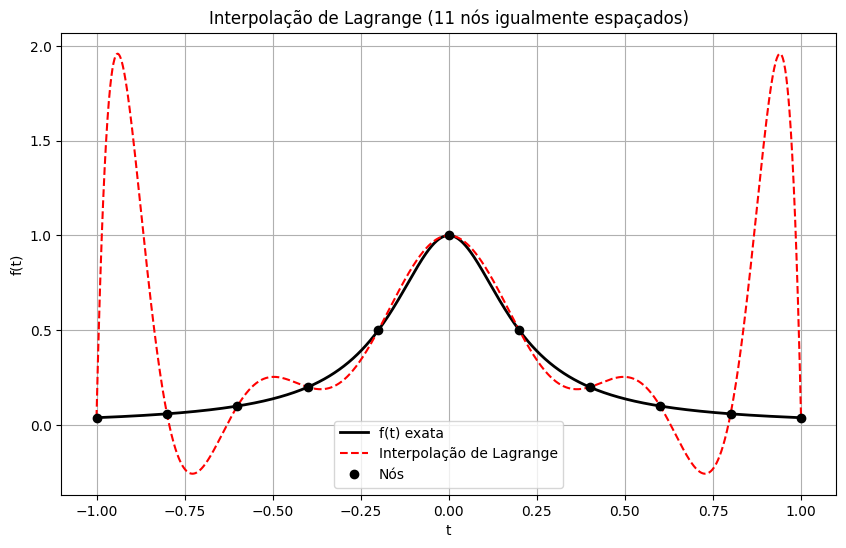

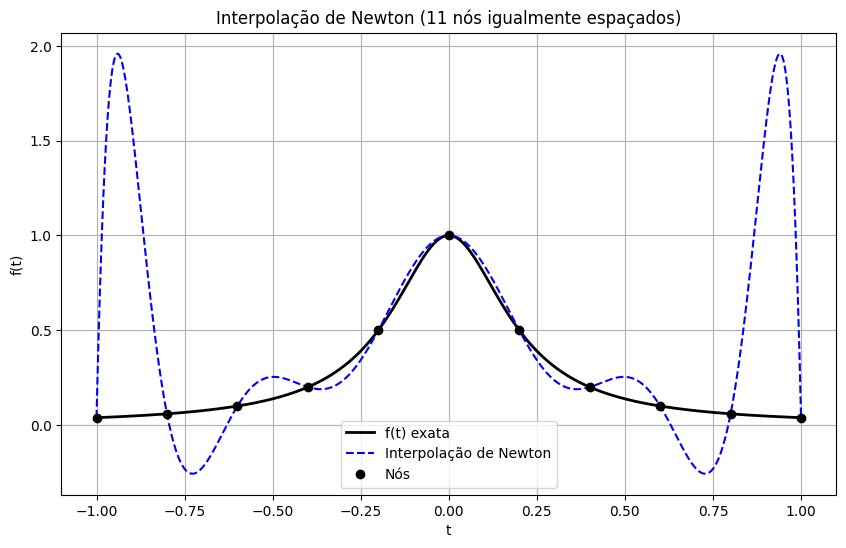

Diferença máxima entre Lagrange e Newton: 2.162714451969805e-13


In [ ]:

# 1) Gerar nós igualmente espaçados
N = 11
t_nodes = get_equispaced_nodes(-1, 1, N)
f_nodes = f_runge(t_nodes)

# 2) Malha densa para plot
t_dense = np.linspace(-1, 1, 2000)
f_dense = f_runge(t_dense)

# 3) Polinômio de Lagrange
f_lagrange = lagrange_interp(t_nodes, f_nodes, t_dense)

# 4) Polinômio de Newton
coeffs_newton = newton_diff_div(t_nodes, f_nodes)
f_newton = newton_interp(t_nodes, coeffs_newton, t_dense)


# ============================
#  GRÁFICO 1 — LAGRANGE
# ============================
plt.figure(figsize=(10,6))
plt.plot(t_dense, f_dense, 'k', label='f(t) exata', linewidth=2)
plt.plot(t_dense, f_lagrange, 'r--', label='Interpolação de Lagrange')
plt.plot(t_nodes, f_nodes, 'ko', label='Nós')
plt.title("Interpolação de Lagrange (11 nós igualmente espaçados)")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()


# ============================
#  GRÁFICO 2 — NEWTON
# ============================
plt.figure(figsize=(10,6))
plt.plot(t_dense, f_dense, 'k', label='f(t) exata', linewidth=2)
plt.plot(t_dense, f_newton, 'b--', label='Interpolação de Newton')
plt.plot(t_nodes, f_nodes, 'ko', label='Nós')
plt.title("Interpolação de Newton (11 nós igualmente espaçados)")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()


# Diferença entre as formas
erro_LN = np.max(np.abs(f_lagrange - f_newton))
print("Diferença máxima entre Lagrange e Newton:", erro_LN)


&nbsp;&nbsp;&nbsp;c-) O que acontece é o fenômeno de Runge. Para a função $f(t) = \frac{1}{1+25t^2}$ e para nós igualmente espaçados, o erro de interpolação (a diferença entre $f(t) e P_n (t)$ não converge para zero uniformemente à medida que o número de pontos N aumenta. Pelo contrário, o erro cresce drasticamente perto das extremidades do intervalo (próximo a t=-1 e t=1).

Isto ocorre pois o termo de erro de interpolação $|f(t) - P_n (t)|$ é limitado por: $$|f(t) - P_n(t)| \leq \frac{1}{(n+1)!} \max_{\xi \in [-1, 1]} |f^{(n+1)}(\xi)| \cdot \left| \prod_{i=0}^{n} (t - t_i) \right|$$

&nbsp;&nbsp;&nbsp;Para nós igualmente espaçados, o produto $|\prod (t-t_i)|$ cresce rapidamente nas bordas, e a taxa de crescimento domina a redução de $\frac{1}{(n+1)!}$, exacerbando as oscilações indesejadas.

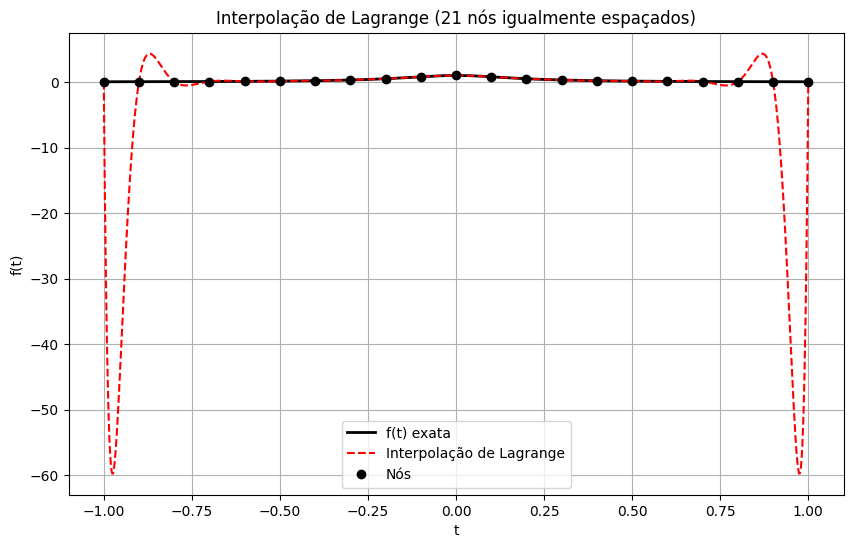

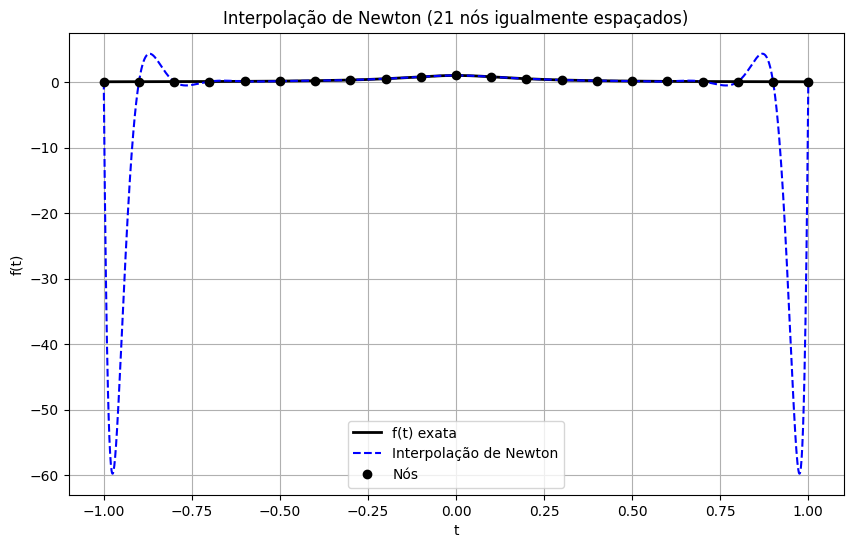

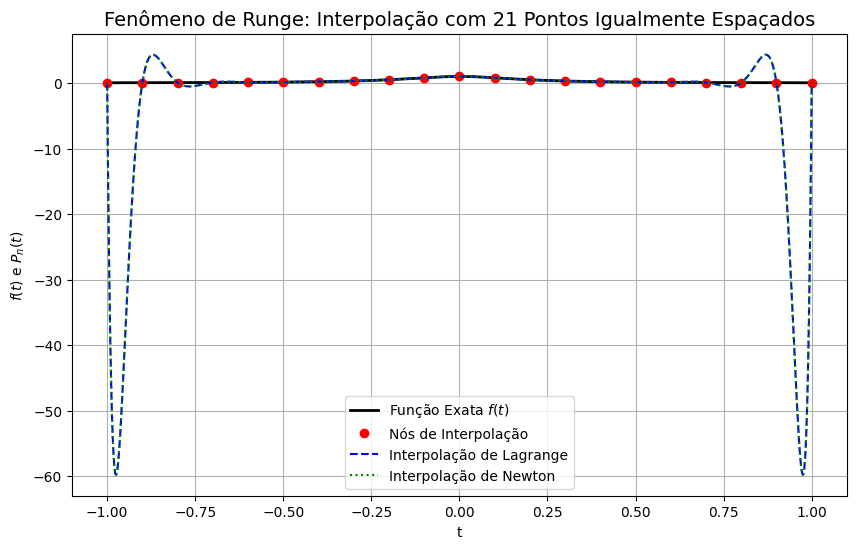

In [ ]:
# Parâmetros para 21 pontos
N_c = 21
t_nodes_c = get_equispaced_nodes(-1, 1, N_c)
f_nodes_c = f_runge(t_nodes_c)

# Lagrange
f_lagrange_c = lagrange_interp(t_nodes_c, f_nodes_c, t_dense)

# Newton
coeffs_newton_c = newton_diff_div(t_nodes_c, f_nodes_c)
f_newton_c = newton_interp(t_nodes_c, coeffs_newton_c, t_dense)

#Gráfico para Lagrange
plt.figure(figsize=(10,6))
plt.plot(t_dense, f_dense, 'k', label='f(t) exata', linewidth=2)
plt.plot(t_dense, f_lagrange_c, 'r--', label='Interpolação de Lagrange')
plt.plot(t_nodes_c, f_nodes_c, 'ko', label='Nós')
plt.title("Interpolação de Lagrange (21 nós igualmente espaçados)")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()


#Gráfico para Newton
plt.figure(figsize=(10,6))
plt.plot(t_dense, f_dense, 'k', label='f(t) exata', linewidth=2)
plt.plot(t_dense, f_newton_c, 'b--', label='Interpolação de Newton')
plt.plot(t_nodes_c, f_nodes_c, 'ko', label='Nós')
plt.title("Interpolação de Newton (21 nós igualmente espaçados)")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()

#Gráfico de comparação dos dois métodos
plot_results(t_dense, f_dense, t_nodes_c, f_lagrange_c, f_newton_c,
             f"Fenômeno de Runge: Interpolação com {N_c} Pontos Igualmente Espaçados")

&nbsp;&nbsp;&nbsp;d-) A interpolação spline é uma alternativa para evitar o fenômeno de Runge. Em vez de usar um único polinômoio de grau alto, ela usa vários polinômios de baixo grau (geralmente cúbico) unidos nos nós de interpolação (pontos de dados)

&nbsp;&nbsp;&nbsp;**spline linear**: conecta os nós com segmentos de reta (polinômios de grau 1). É a interpolação mais simples e garante continuidade $C⁰$.

&nbsp;&nbsp;&nbsp;**spline cúbico**: usa poninômios de grau 3 entre cada par de nós. Garante continuide $C²$ (a própria função, sua primeira e segunda derivadas são contínuas nos nós), resultando em curvas muito suaves.

&nbsp;&nbsp;&nbsp;**condições de contorno naturais**: para o spline cúbico, as condições de contorno naturais impõem que a segunda derivada de spline seja zero nas extremidades do intervalo $(S"(-1)=S"(1)=0)$.

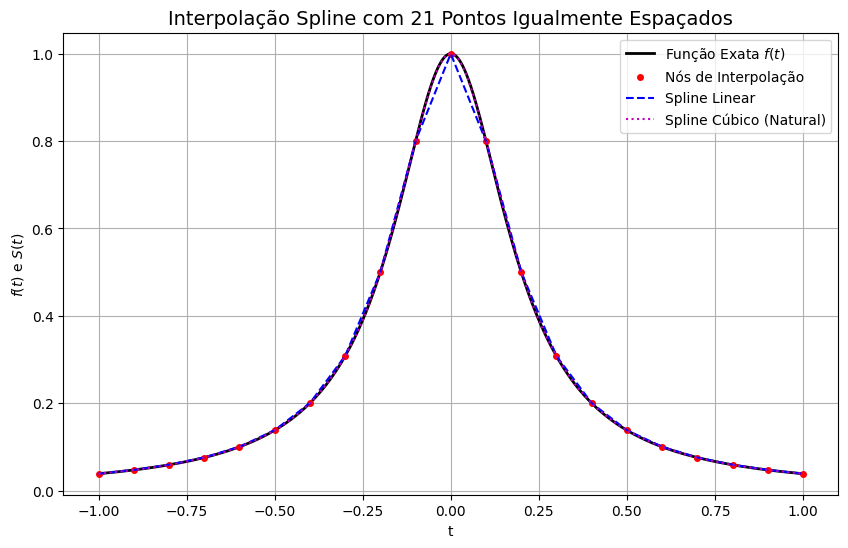

In [ ]:
from scipy.interpolate import interp1d, CubicSpline

# 21 pontos igualmente espaçados
N_d = 21
t_nodes_d = get_equispaced_nodes(-1, 1, N_d)
f_nodes_d = f_runge(t_nodes_d)

# 1. Spline Linear (scipy.interpolate.interp1d com kind='linear')
spline_linear = interp1d(t_nodes_d, f_nodes_d, kind='linear')
f_spline_linear = spline_linear(t_dense)

# 2. Spline Cúbico (scipy.interpolate.CubicSpline com bc_type='natural')
spline_cubico = CubicSpline(t_nodes_d, f_nodes_d, bc_type='natural')
f_spline_cubico = spline_cubico(t_dense)

# Plot Comparativo
plt.figure(figsize=(10, 6))
plt.plot(t_dense, f_dense, 'k', label='Função Exata $f(t)$', linewidth=2)
plt.plot(t_nodes_d, f_nodes_d, 'ro', label='Nós de Interpolação', markersize=4)
plt.plot(t_dense, f_spline_linear, 'b--', label='Spline Linear', linewidth=1.5)
plt.plot(t_dense, f_spline_cubico, 'm:', label='Spline Cúbico (Natural)', linewidth=1.5)
plt.title(f"Interpolação Spline com {N_d} Pontos Igualmente Espaçados", fontsize=14)
plt.xlabel('t')
plt.ylabel('$f(t)$ e $S(t)$')
plt.legend()
plt.grid(True)
plt.show()


&nbsp;&nbsp;&nbsp;e-) Os nós de Chebyshev são a solução canôninca para mitigar o Fenômeno de Runge. Eles são nós não igualmente espaçados, concnetrados mais densamente nas extremidades do intervalo [-1,1].

&nbsp;&nbsp;&nbsp;Para um intervalo [-1,1], os N nós de Chebyshev de grau n = N-1 são dados por: $$t_i = \cos \left( \frac{(2i + 1)\pi}{2N} \right), \quad i = 0, 1, \ldots, N - 1$$

&nbsp;&nbsp;&nbsp;O uso desses nós minimiza o termo $|\prod(t-t_i)|$ no erro, garantindo que o erro de interpolação converja unidormemente para zero, mesmo para a função de Runge.

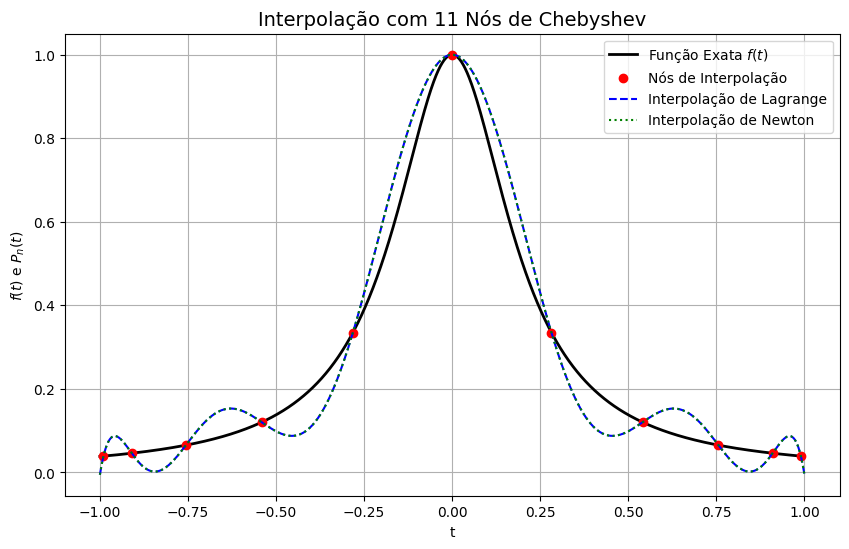

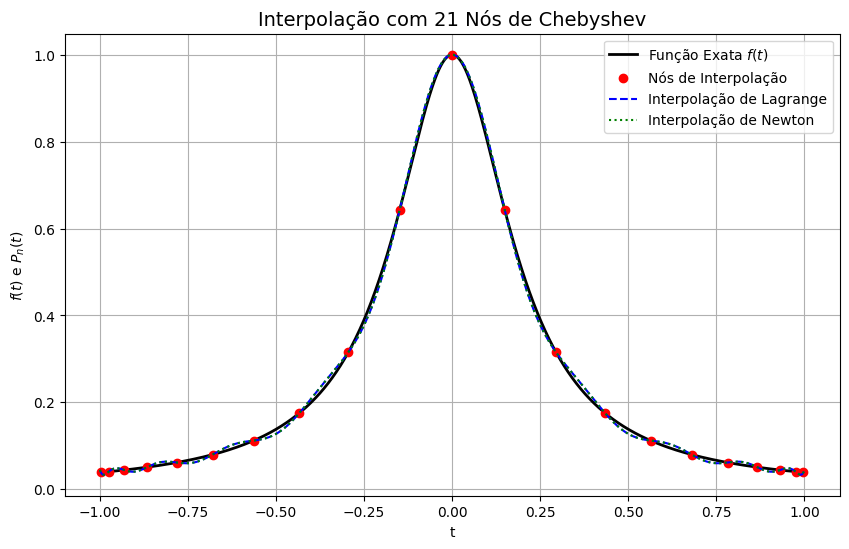

In [ ]:
# Função para gerar Nós de Chebyshev no intervalo [-1, 1]
a=-1
b=1

def get_chebyshev_nodes(a, b, N):
    """
    Gera N nós de Chebyshev no intervalo [a, b].
    Argumentos:
        a (float): Limite inferior do intervalo.
        b (float): Limite superior do intervalo.
        N (int): Número de nós a serem gerados.
    Retorna:
        numpy.ndarray: Array contendo os nós de Chebyshev.
    """
    i = np.arange(N)
    # Fórmula padrão para gerar nós de Chebyshev no intervalo [-1, 1]
    t_cheb = np.cos((2 * i + 1) * np.pi / (2 * N))

    # Mapeamento linear dos nós do intervalo [-1, 1] para o intervalo [a, b]
    # Esta etapa é generalizável, mas no contexto atual (a=-1, b=1) ela não altera os valores.
    if a != -1.0 or b != 1.0:
         t_cheb = 0.5 * (a + b) + 0.5 * (b - a) * t_cheb

    return t_cheb

# Parâmetros: Repetir b (11 pontos) e c (21 pontos)
N_e1 = 11
N_e2 = 21

# --- 1. 11 Pontos de Chebyshev ---
t_nodes_e1 = get_chebyshev_nodes(a, b, N_e1)
f_nodes_e1 = f_runge(t_nodes_e1)

f_lagrange_e1 = lagrange_interp(t_nodes_e1, f_nodes_e1, t_dense)
coeffs_newton_e1 = newton_diff_div(t_nodes_e1, f_nodes_e1)
f_newton_e1 = newton_interp(t_nodes_e1, coeffs_newton_e1, t_dense)

plot_results(t_dense, f_dense, t_nodes_e1, f_lagrange_e1, f_newton_e1,
             f"Interpolação com {N_e1} Nós de Chebyshev")

# --- 2. 21 Pontos de Chebyshev ---
t_nodes_e2 = get_chebyshev_nodes(a, b, N_e2)
f_nodes_e2 = f_runge(t_nodes_e2)

f_lagrange_e2 = lagrange_interp(t_nodes_e2, f_nodes_e2, t_dense)
coeffs_newton_e2 = newton_diff_div(t_nodes_e2, f_nodes_e2)
f_newton_e2 = newton_interp(t_nodes_e2, coeffs_newton_e2, t_dense)

plot_results(t_dense, f_dense, t_nodes_e2, f_lagrange_e2, f_newton_e2,
             f"Interpolação com {N_e2} Nós de Chebyshev")

-------------------------------------

&nbsp;&nbsp;&nbsp;Exercício 5: a-) O método dos mínimos quadrados busca encontrar os parâmetros de uma função que minimizem a soma dos quadrados dos erros (resíduos) entre os dados observados (y) e os valores preditos pelo modelo.

&nbsp;&nbsp;&nbsp;Os dois códigos fornecidos implementam a solução MMQ para o ajuste de um polinômio de grau k-1 (onde k é o número de coeficientes $a_0,\cdots,a_{k-1}$), mas utilizam médotos diferentes para resolver o sistema linear resultante.

&nbsp;&nbsp;&nbsp;**Função mmq(x,y,k): Solução via equações normais**

&nbsp;&nbsp;&nbsp;Esta função resolve o sistema de equações normais diretamente: $Aa=b$, onde $A=X^T X e b=X^T y.$

&nbsp;&nbsp;&nbsp;O que está sendo calculado: os coeficiente do polinômio $P_{k-1}(x)$ que minimizam o erro quadrático, através da solução do sistema de equações normais.

&nbsp;&nbsp;&nbsp;**Função mmq(x,y,k): Solução via Decomposição QR**

&nbsp;&nbsp;&nbsp;Esta função utiliza a Decomposição QR de X para resolver o problema dos Mínimos quadados, o que é numericamente mais estável que resolver as equações normais. A decomposição QR de X é X=QR, onde Q é uma matriz ortogonal e R é uma matriz triangular superior. Substituindo na expressão do erro e simplificando, a solução a é dada pelo sistema: $$Ra=Q^Ty$$

&nbsp;&nbsp;&nbsp;O que está sendo calculado: os coeficientes do polinômio $P_{k-1}(x)$ que minimizam o erro quadrático, resolvendo o sistema linear via decomposição QR, que é preferível por sua estabilidade numérica.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def mmq(x, y, k):
    X = np.vander(x, k)         #Cria a matrix Vandermonde X de tamanho n x k
    A = np.transpose(X).dot(X)  #Calcula a matriz A = X^(T)*X
    b = np.transpose(X).dot(y)  #Calcula o vetor b = X^(T)*y
    a = np.linalg.solve(A, b)   #Resolve o sistema linear Aa=b
    return a


def mmq_QR(x, y, k):
    X = np.vander(x, k)         #Cria a matriz de Vandermonde X
    (Q, R) = np.linalg.qr(X)    #Calcula a Decomposição QR de X
    b = np.transpose(Q).dot(y)  #Calcula o termo do lado direito Q^T*y
    a = np.linalg.solve(R, b)   #Resolve o sistema linear Ra=b para encontrar o vetor de coeficientes a.
    return a                    #Como R é triangular superior, este sistema é resolvido de forma eficiente (subtituição reversa)


&nbsp;&nbsp;&nbsp;b-) A função exponencial não é linear nos parâmetros a e b. Para utilizar o método dos mínimos quadrados é necessário linearizá-la aplicando o logaritmo natural (base 10): $$g(x)=ab^x$$ $$ln(g(x))=ln(a)+ln(b)*x$$

&nbsp;&nbsp;&nbsp;Fazendo as substituições: $$Y=ln(g(x))$$ $$A=ln(a)$$ $$B=ln(b)$$

&nbsp;&nbsp;&nbsp;Obtem-se o modelo linear: $$Y=A+Bx$$

&nbsp;&nbsp;&nbsp;Este é um ajuste de reta para os dados transformados.

--- 5. b) Ajuste Exponencial g(x) = a * b^x (Completo) ---
Coeficientes do ajuste linear (Y = A + Bx): A = 3.4587, B = 0.1056
Coeficientes do ajuste exponencial (g(x) = a * b^x): a = 31.7748, b = 1.1114


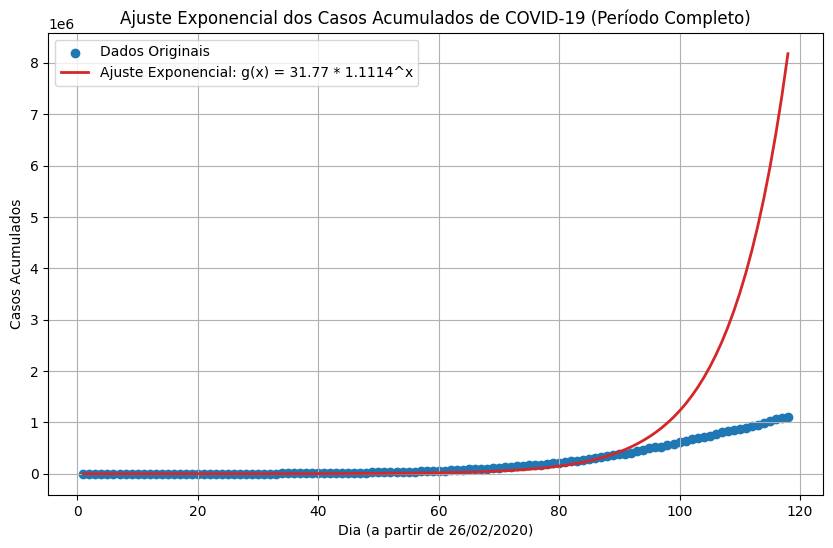

In [ ]:

# Carregamento dos dados
# Os dados são o número de casos acumulados.
# O índice do array servirá como 'x' (dias a partir de 26/02/2020)
try:
    with open('casosacumuladosbrasilatualizado.txt', 'r') as f:
        y_data = np.array([int(line.strip()) for line in f if line.strip()])
except FileNotFoundError:
    print("Arquivo 'casosacumuladosbrasilatualizado.txt' não encontrado.")
    y_data = np.array([])

if y_data.size == 0:
    print("Dados vazios. Não é possível continuar a execução do Exercício 5.")
    exit()

# Dados completos (26 de fev a 18 de jun)
n_dias = y_data.size
x_data = np.arange(1, n_dias + 1) # Dias 1, 2, ..., n

## Ajuste Exponencial g(x) = a * b^x (Linearização)
# 1. Transformar y para Y = ln(y)
# Filtra pontos onde y > 0 para evitar ln(0)
valid_indices = y_data > 0
x_exp = x_data[valid_indices]
y_exp = y_data[valid_indices]
Y_exp = np.log(y_exp)

# 2. Ajuste de reta Y = A + Bx. k=2 para o grau 1 (x^1 e x^0)
# A função mmq/mmq_QR retorna [coeficiente_x, coeficiente_constante]
coef_linear = mmq_QR(x_exp, Y_exp, k=2)
# coef_linear = [B, A]
B = coef_linear[0]
A = coef_linear[1]

# 3. Retornar aos parâmetros originais
b = np.exp(B)
a = np.exp(A)

print(f"--- 5. b) Ajuste Exponencial g(x) = a * b^x (Completo) ---")
print(f"Coeficientes do ajuste linear (Y = A + Bx): A = {A:.4f}, B = {B:.4f}")
print(f"Coeficientes do ajuste exponencial (g(x) = a * b^x): a = {a:.4f}, b = {b:.4f}")

# Função exponencial ajustada
def g(x):
    return a * (b ** x)

# Plotagem
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, label='Dados Originais', color='tab:blue', marker='o')
plt.plot(x_data, g(x_data), label=f'Ajuste Exponencial: g(x) = {a:.2f} * {b:.4f}^x', color='tab:red', linewidth=2)
plt.title('Ajuste Exponencial dos Casos Acumulados de COVID-19 (Período Completo)')
plt.xlabel('Dia (a partir de 26/02/2020)')
plt.ylabel('Casos Acumulados')
plt.legend()
plt.grid(True)
plt.show()

&nbsp;&nbsp;&nbsp;c-) O modelo polinomial $P_m(x)$ é linear nos parâmetros $a_i$, então as funções mmq ou mmq_QR podem ser aplicadas diretamente com k = m+1 (o número de coeficientes é m+1, de $a_0$ a $a_m$)

Grau m=4: Coeficientes (a_4 a_0): [-2.03246061e-03  1.92800643e+00 -1.45345321e+02  3.42821378e+03
 -1.77417366e+04]
Grau m=5: Coeficientes (a_5 a_0): [-2.93632626e-04  8.53232457e-02 -7.33218782e+00  2.70555196e+02
 -3.76305777e+03  1.24704590e+04]
Grau m=6: Coeficientes (a_6 a_0): [-3.62119198e-06  9.99132910e-04 -8.97992444e-02  3.83554355e+00
 -6.52923671e+01  3.36903939e+02 -1.29809024e+02]


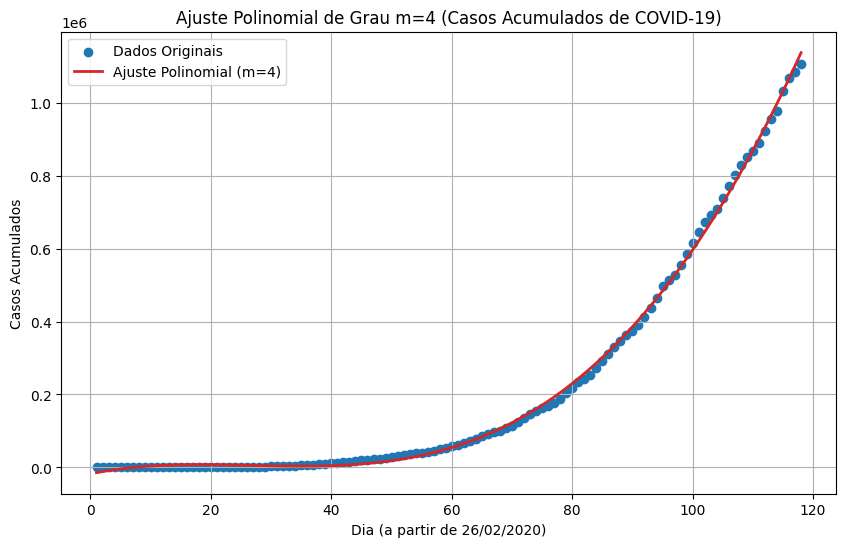

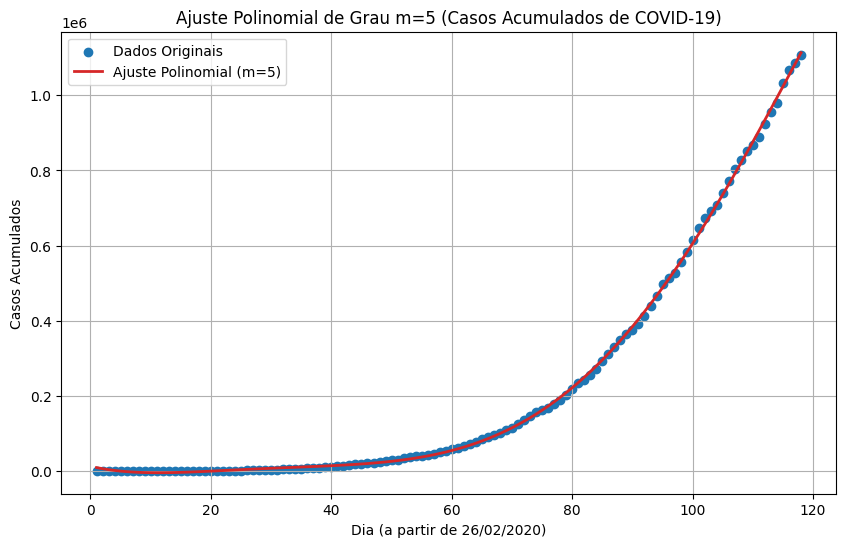

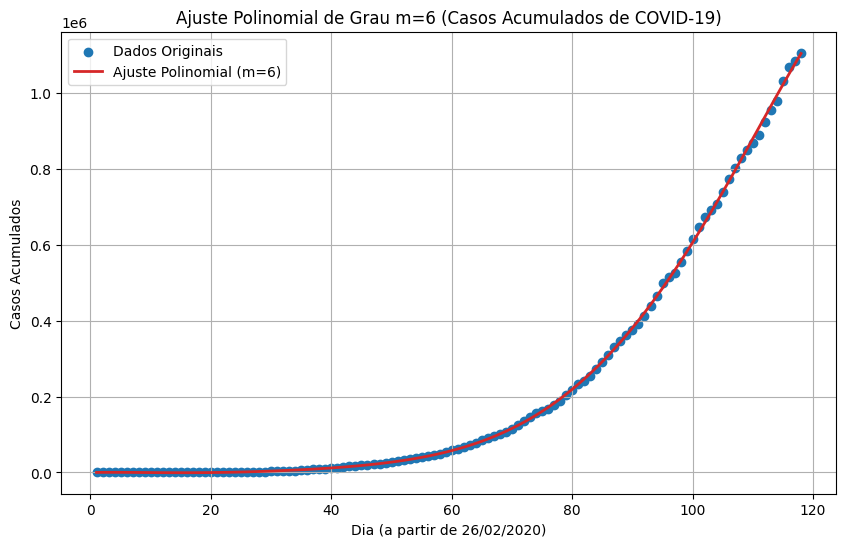

In [ ]:

# Parâmetros
graus = [4, 5, 6]

# Dicionário para armazenar os coeficientes
coeficientes_polinomiais = {}

for m in graus:
    k = m + 1 # k é o número de coeficientes (grau + 1)

    # 1. Ajuste Polinomial P_m(x) = a_m*x^m + ... + a_0
    coefs = mmq_QR(x_data, y_data, k=k)
    coeficientes_polinomiais[m] = coefs

    # 2. Plotagem Individual
    plt.figure(figsize=(10, 6))

    # Plotar os dados originais
    plt.scatter(x_data, y_data, label='Dados Originais', color='tab:blue', marker='o')

    # Plotar o ajuste específico
    # np.polyval usa os coeficientes na ordem decrescente: [a_m, ..., a_0]
    y_fit = np.polyval(coefs, x_data)
    plt.plot(x_data, y_fit,
             label=f'Ajuste Polinomial (m={m})',
             color='tab:red',
             linewidth=2,
             linestyle='-')

    plt.title(f'Ajuste Polinomial de Grau m={m} (Casos Acumulados de COVID-19)')
    plt.xlabel('Dia (a partir de 26/02/2020)')
    plt.ylabel('Casos Acumulados')
    plt.legend()
    plt.grid(True)


# Imprimir os coeficientes
for m, coefs in coeficientes_polinomiais.items():
    print(f"Grau m={m}: Coeficientes (a_{m} a_0): {coefs}")


&nbsp;&nbsp;&nbsp;d-) O erro de truncamento (ou erro quadrático) E é a soma dos quadrados dos resíduos (diferença entre o valor real e o valor ajustado): $$E= \sum_{i=1}^{n}(y_i-f(x_i))²$$

In [ ]:

# 1. Erro para o Ajuste Exponencial g(x)
y_pred_exp = g(x_data)
erro_exp = np.sum((y_data - y_pred_exp)**2)
print(f"Erro Quadrático (g(x) = a*b^x): E = {erro_exp:.2f}")

# 2. Erro para o Ajuste Polinomial P_m(x)
erros_polinomiais = {}
for m in graus:
    y_pred_pol = p_m(x_data, m)
    erro_pol = np.sum((y_data - y_pred_pol)**2)
    erros_polinomiais[m] = erro_pol
    print(f"Erro Quadrático (P_{m}(x)): E = {erro_pol:.2f}")

# Comparação
print("\nConclusão do Erro:")
# O erro diminui à medida que o grau do polinômio aumenta (m=4 -> m=6).
# O ajuste exponencial tem um erro muito maior que os ajustes polinomiais,
# indicando que para os dados completos o modelo exponencial (linearizado)
# não é o melhor ajustador dos dados.
if erro_exp < min(erros_polinomiais.values()):
    melhor_ajuste = 'Exponencial'
    melhor_erro = erro_exp
else:
    melhor_grau = min(erros_polinomiais, key=erros_polinomiais.get)
    melhor_ajuste = f'Polinomial (m={melhor_grau})'
    melhor_erro = erros_polinomiais[melhor_grau]

print(f"O **melhor ajuste** para o período completo, com o menor erro quadrático ({melhor_erro:.2f}), é o **{melhor_ajuste}**.")

Erro Quadrático (g(x) = a*b^x): E = 227755039740919.66
Erro Quadrático (P_4(x)): E = 11705224375.21
Erro Quadrático (P_5(x)): E = 4112452264.92
Erro Quadrático (P_6(x)): E = 3103104035.70

Conclusão do Erro:
O **melhor ajuste** para o período completo, com o menor erro quadrático (3103104035.70), é o **Polinomial (m=6)**.


&nbsp;&nbsp;&nbsp; e-) e f-) Ambos pedem a repetição dos itens anteriores para dois subconjuntos de dados (20 primeiros dias e 50 últimos dias)

# 20 Primeiros Dias (20 dias) #

* **AJUSTE EXPONENCIAL (g(x) = a * b^x)**
  - Coeficientes: a = 0.4349, b = 1.3717
  - **Erro Quadrático (E)**: 860.15

* **AJUSTE POLINOMIAL (P_m(x))**
  - Grau m=4 | Erro Quadrático (E): 707.65
  - Grau m=5 | Erro Quadrático (E): 699.52
  - Grau m=6 | Erro Quadrático (E): 641.19


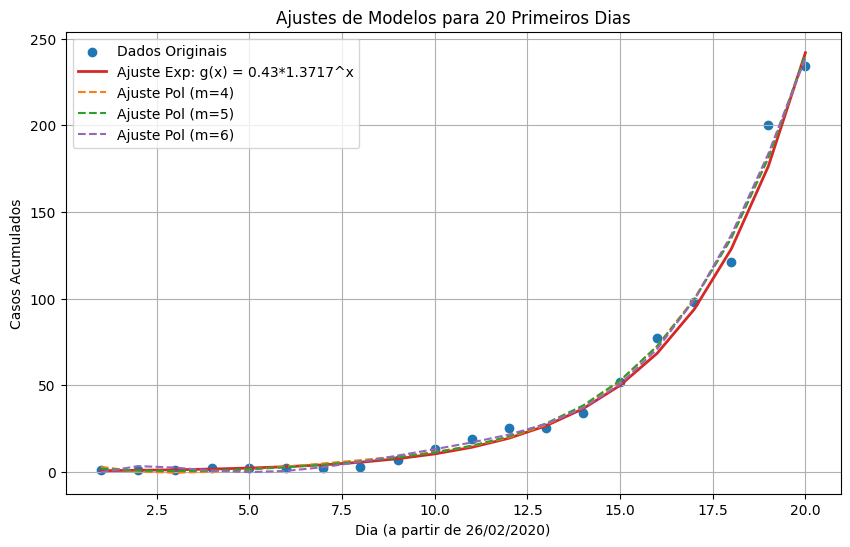

# 50 Últimos Dias (50 dias) #

* **AJUSTE EXPONENCIAL (g(x) = a * b^x)**
  - Coeficientes: a = 4793.5224, b = 1.0488
  - **Erro Quadrático (E)**: 177783990775.80

* **AJUSTE POLINOMIAL (P_m(x))**
  - Grau m=4 | Erro Quadrático (E): 2682107211.16
  - Grau m=5 | Erro Quadrático (E): 2258915906.22
  - Grau m=6 | Erro Quadrático (E): 2213282285.62


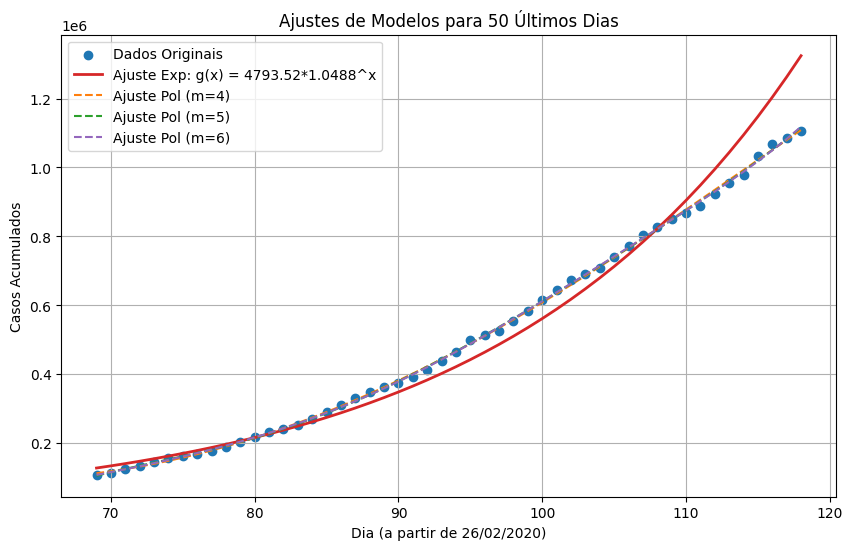

In [ ]:
# Continuação do código anterior

def realizar_analise(x_sub, y_sub, nome_periodo):
    n_sub = y_sub.size
    graus = [4, 5, 6]

    # --- Ajuste Exponencial g(x) = a * b^x (Linearização) ---
    valid_indices = y_sub > 0
    x_exp = x_sub[valid_indices]
    y_exp = y_sub[valid_indices]
    Y_exp = np.log(y_exp)

    # Verifica se há dados suficientes para ajuste (mínimo 2 pontos)
    if x_exp.size < 2:
        print(f"Não há dados suficientes ({x_exp.size} pontos > 0) para o ajuste exponencial em {nome_periodo}.")
        return

    coef_linear = mmq_QR(x_exp, Y_exp, k=2)
    B = coef_linear[0]
    A = coef_linear[1]
    b = np.exp(B)
    a = np.exp(A)

    def g_sub(x):
        return a * (b ** x)

    y_pred_exp = g_sub(x_sub)
    erro_exp = np.sum((y_sub - y_pred_exp)**2)

    # --- Ajuste Polinomial P_m(x) ---
    coeficientes_polinomiais = {}
    erros_polinomiais = {}

    for m in graus:
        k = m + 1
        # Verifica se há dados suficientes para o grau (m+1 coeficientes)
        if n_sub < k:
            erros_polinomiais[m] = np.inf
            continue

        coefs = mmq_QR(x_sub, y_sub, k=k)
        coeficientes_polinomiais[m] = coefs

        y_pred_pol = np.polyval(coefs, x_sub)
        erro_pol = np.sum((y_sub - y_pred_pol)**2)
        erros_polinomiais[m] = erro_pol

    # --- Resultados ---
    print(f"# {nome_periodo} ({n_sub} dias) #")

    print(f"\n* **AJUSTE EXPONENCIAL (g(x) = a * b^x)**")
    print(f"  - Coeficientes: a = {a:.4f}, b = {b:.4f}")
    print(f"  - **Erro Quadrático (E)**: {erro_exp:.2f}")

    print(f"\n* **AJUSTE POLINOMIAL (P_m(x))**")
    for m in graus:
        erro = erros_polinomiais[m]
        if erro == np.inf:
            print(f"  - Grau m={m}: Não foi possível ajustar (dados insuficientes)")
        else:
            print(f"  - Grau m={m} | Erro Quadrático (E): {erro:.2f}")

    # Plotagem
    plt.figure(figsize=(10, 6))
    plt.scatter(x_sub, y_sub, label='Dados Originais', color='tab:blue', marker='o')

    plt.plot(x_sub, g_sub(x_sub), label=f'Ajuste Exp: g(x) = {a:.2f}*{b:.4f}^x', color='tab:red', linewidth=2)

    cores = ['tab:orange', 'tab:green', 'tab:purple']
    for i, m in enumerate(graus):
        if m in coeficientes_polinomiais:
             plt.plot(x_sub, np.polyval(coeficientes_polinomiais[m], x_sub), label=f'Ajuste Pol (m={m})', color=cores[i], linestyle='--')

    plt.title(f'Ajustes de Modelos para {nome_periodo}')
    plt.xlabel('Dia (a partir de 26/02/2020)')
    plt.ylabel('Casos Acumulados')
    plt.legend()
    plt.grid(True)
    plt.show()

# 5. e) 20 Primeiros Dias
dias_e = 20
x_e = x_data[:dias_e]
y_e = y_data[:dias_e]
realizar_analise(x_e, y_e, "20 Primeiros Dias")

# 5. f) 50 Últimos Dias
dias_f = 50
x_f = x_data[-dias_f:]
y_f = y_data[-dias_f:]
realizar_analise(x_f, y_f, "50 Últimos Dias")

&nbsp;&nbsp;&nbsp;g-) Os resultados fornecem uma base para comparar a adequação da função exponencial ($g(x)=ab^x$) e dos polinômios ($P_m(x)$ para m = 4,5,6) em diferentes estágios da progressão da doença.

| Modelo | Desempenho na Fase Inicial (20 Dias) | Desempenho na Fase de Aceleração (50 Dias) |
| :--- | :--- | :--- |
| **Exponencial** ($g(x) = a b^x$) | **Ajuste de Alta Qualidade** ($E \approx 860.15$). A taxa de crescimento $b \approx 1.37$ reflete o crescimento livre e rápido. | **Falha Crítica** ($E \approx 1.77 \times 10^{12}$). O erro é alto devido à taxa de crescimento $b$ ter caído para $\approx 1.05$, provando que a premissa de taxa constante não se sustenta no longo prazo. |
| **Polinomial** ($P_m(x)$) | **Numericamente Superior** ($E \approx 641.19$ para $m = 6$). O ajuste é quase perfeito, com $RMSE$ de apenas $\approx 5.66$ casos. | **Melhor Ajustador** ($E \approx 2.21 \times 10^{11}$ para $m = 6$). Embora o erro seja alto em magnitude, ele é **8 vezes menor** que o do exponencial, mostrando a flexibilidade necessária para modelar a curva complexa. |


&nbsp;&nbsp;&nbsp; **Informação essencial fornecida pelos dados**:

&nbsp;&nbsp;&nbsp;A análise comparativa e a variação dos erros e parâmetros ao longo do tempo fornecem duas informações cruciais sobre a natureza da curva de casos acumulados:

&nbsp;&nbsp;&nbsp;**A dinâmica da epidemia é intrinsicamente não linear**

&nbsp;&nbsp;&nbsp;Os dados confirmam que a pandemia não segue um modelo exponencial simples de forma sustentada. A alta performance do modelo exponencial e o erro extremamente baixo no período inicial validam a fase de crescimento exponencial ideal, esta é a fase em que o contágio é livre e a taxa de reprodução é alta. Contudo, a disparidade colossal no erro do exponencial entre os períodos (de $E \approx 860$ para $E\approx 1.77x10^{12}$) prova que a taxa de crescimento b não é constante. Essa queda se deve à intervenção de fatores externos (medidas de isolamento) e à dinâmica interna da população (menos indivíduos suscetíveis). O modelo exponencial simples torna-se inadequado após o início.

&nbsp;&nbsp;&nbsp;**Necessidade de modelos flexíveis e teóricos**

&nbsp;&nbsp;&nbsp;A comparação dos modelos indica a melhor abordagem para a modelagem da curva. A grande flexibilidade é a característica que faz com que o polinômio de grau m = 6 seja o mais adequado para descrever numericamente o conjunto de dados, pois ele se adapta melhor às acelerações e desacelerações da curva real, minimizando o erro quadrático em todas as fases. Porém, ele ainda é limitado pela regressão, o fato de o modelo mais preciso ser um polinômio empírico reforça que o fenômeno é complexo. Para explicar a dinâmica, e não apenas descrevê-la, e fazer previsões confiáveis, são necessários modelos epidemiológicos dinâmicos que consideram variáveis como população suscetível, infectada e recuperada, e não apenas modelos de regressão simples.